In [4]:
# Sprawdzenie, czy wszystkie wymiary są takie same

from PIL import Image
import os

folder_path = 'Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio'

sizes = []
for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        img = Image.open(os.path.join(folder_path, filename))
        sizes.append((filename, img.size))

unique_sizes = set(size for _, size in sizes)

if len(unique_sizes) == 1:
    print("Wszystkie obrazy mają te same wymiary:", unique_sizes.pop())
else:
    print("Obrazy mają różne wymiary:")
    for name, size in sizes:
        print(f"{name}: {size}")

Wszystkie obrazy mają te same wymiary: (600, 600)


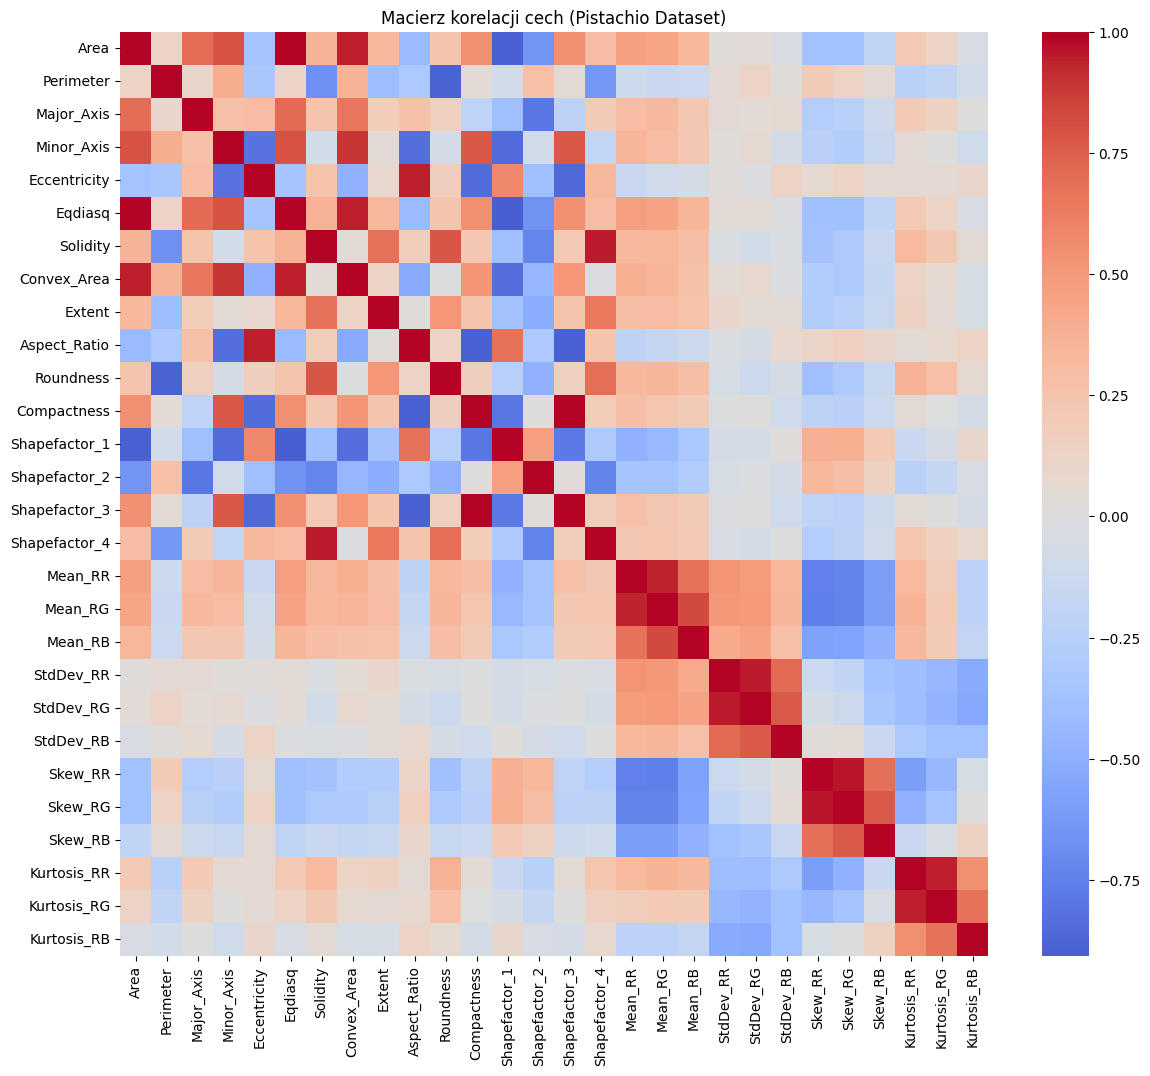

In [56]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel("Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx", sheet_name=0, engine='openpyxl')
df = data.copy()

df= df.drop(columns=['Class'])

corr_matrix = features.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech (Pistachio Dataset)')
plt.show()

In [57]:
# proby wybrania cech

from sklearn.feature_selection import VarianceThreshold

# usuwamy cechy z niska wariancja
sel = VarianceThreshold(threshold=0.01)
X_reduced = sel.fit_transform(df)

In [58]:
print(X_reduced)

[[6.339100e+04 1.568405e+03 3.903396e+02 ... 2.969200e+00 3.057600e+00
  2.954200e+00]
 [6.835800e+04 1.942187e+03 4.108594e+02 ... 1.980700e+00 2.100600e+00
  2.215200e+00]
 [7.358900e+04 1.246538e+03 4.523630e+02 ... 3.542000e+00 3.685600e+00
  4.101200e+00]
 ...
 [1.011360e+05 1.255619e+03 4.752161e+02 ... 3.311200e+00 3.430600e+00
  3.069700e+00]
 [9.740900e+04 1.195215e+03 4.521823e+02 ... 3.423700e+00 2.960600e+00
  3.003300e+00]
 [7.846600e+04 2.356908e+03 4.459131e+02 ... 2.527800e+00 2.224800e+00
  2.448000e+00]]


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from itertools import combinations
import numpy as np

X_array = X_reduced.values if hasattr(X_reduced, 'values') else X_reduced

best_score = -1
best_features = None

for comb in combinations(range(X_array.shape[1]), 6):  
    X_sub = X_array[:, list(comb)] 
    labels = KMeans(n_clusters=3).fit_predict(X_sub)
    score = silhouette_score(X_sub, labels)
    
    if score > best_score:
        best_score = score
        best_features = comb

print("Najlepsze cechy:", best_features)

In [60]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from itertools import combinations
import numpy as np

X_array = df.values if hasattr(df, 'values') else df

# 1. PCA do 10 wymiarów
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_array)

# 2. Szukamy najlepszych kombinacji po 3 cechy w PCA
best_score = -1
best_features = None

for comb in combinations(range(10), 3):
    X_sub = X_pca[:, list(comb)]
    labels = KMeans(n_clusters=3).fit_predict(X_sub)
    score = silhouette_score(X_sub, labels)
    if score > best_score:
        best_score = score
        best_features = comb

print("Najlepsze cechy PCA:", best_features)
print("Najlepszy silhouette score:", best_score)

Najlepsze cechy PCA: (1, 5, 6)
Najlepszy silhouette score: 0.6108073592409603


In [62]:
print(X_pca)

[[-2.00873930e+04 -3.36167226e+03 -5.85403635e+01 ...  4.37554818e+00
   3.93880490e-01  1.43882619e+00]
 [-1.31574761e+04 -3.28685964e+03  2.88445708e+02 ... -3.79445630e-01
  -2.01513026e+00 -8.23267426e-01]
 [-7.87893935e+03 -1.11061783e+03 -2.40429368e+02 ... -2.23549890e+00
   2.67241350e-01  7.32851663e-01]
 ...
 [ 2.71872492e+04  2.82132687e+03 -5.35703758e+01 ... -2.78621076e+00
  -1.07100770e+00 -3.13333792e+00]
 [ 2.17866539e+04  2.94589348e+03 -7.59933625e+01 ... -1.12973775e+00
  -4.37435556e-01  8.14817471e-01]
 [ 2.90380272e+03 -5.05023467e+03  4.65559443e+02 ...  5.43761222e+00
  -7.56024911e+00  5.80508953e+00]]


In [22]:
#ręcznie wybierane
selected_features = [
    'Area',
    'Mean_RB',
    'Skew_RB',
    'Kurtosis_RG',
    'Roundness',
    'StdDev_RR',
    'Shapefactor_3'
    
]

In [63]:
df_selected = X_pca[:, [1, 5, 6]]

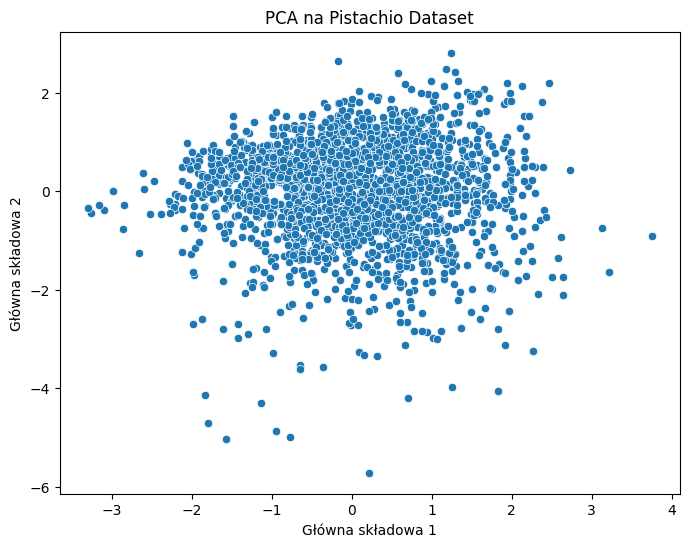

In [67]:
X = df_selected

# standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])


plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title('PCA na Pistachio Dataset')
plt.xlabel('Główna składowa 1')
plt.ylabel('Główna składowa 2')
plt.show()

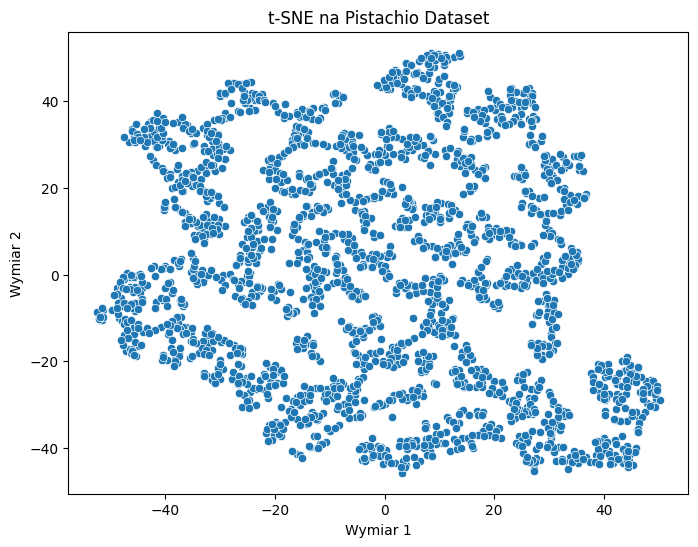

In [69]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


# standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2')
plt.title('t-SNE na Pistachio Dataset')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()


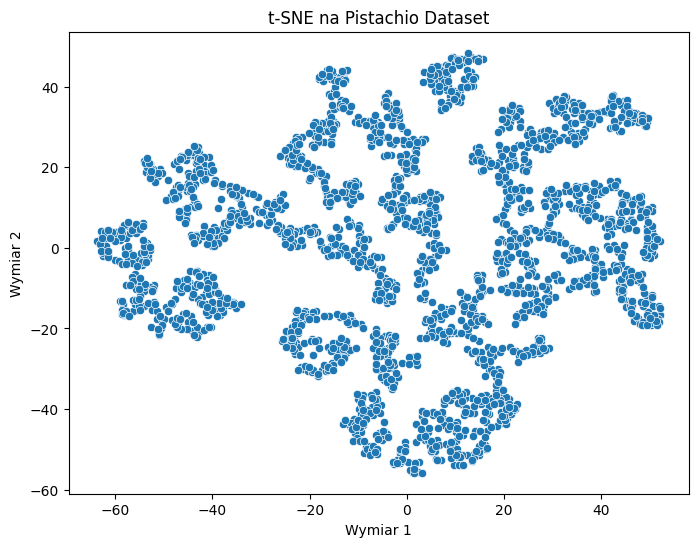

In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2')
plt.title('t-SNE na Pistachio Dataset')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()

Sprawdzam czy jakiekolwiek modele działają 

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
# 📏 Standaryzacja cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tsne)

# 🔍 KMeans z 2 klastrami (bo są 2 typy pistacji)
kmeans = KMeans(n_clusters=3, random_state=42)
labels_pred = kmeans.fit_predict(X_scaled)

# 📈 Ocena jakości klastrów
sil_score = silhouette_score(X_scaled, labels_pred)
print(f"Silhouette Score: {sil_score:.2f}")


Silhouette Score: 0.42


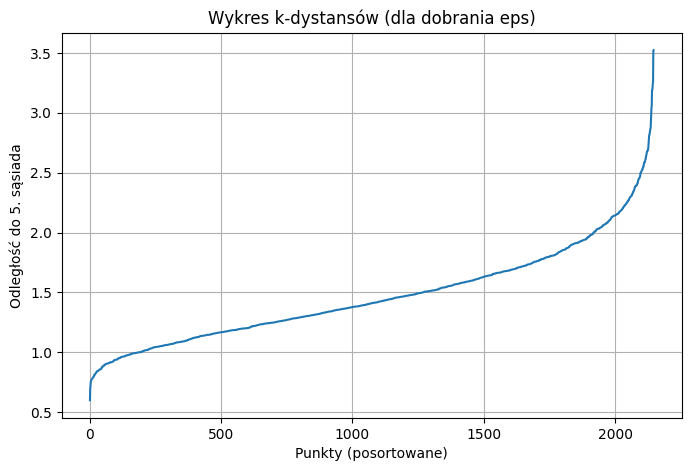

In [72]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Załóżmy, że X_tsne to twoje dane po t-SNE
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_tsne)
distances, indices = neighbors_fit.kneighbors(X_tsne)

# Posortowane odległości do 5-tego najbliższego sąsiada
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("Wykres k-dystansów (dla dobrania eps)")
plt.xlabel("Punkty (posortowane)")
plt.ylabel("Odległość do 5. sąsiada")
plt.grid(True)
plt.show()

Liczba znalezionych klastrów: 1


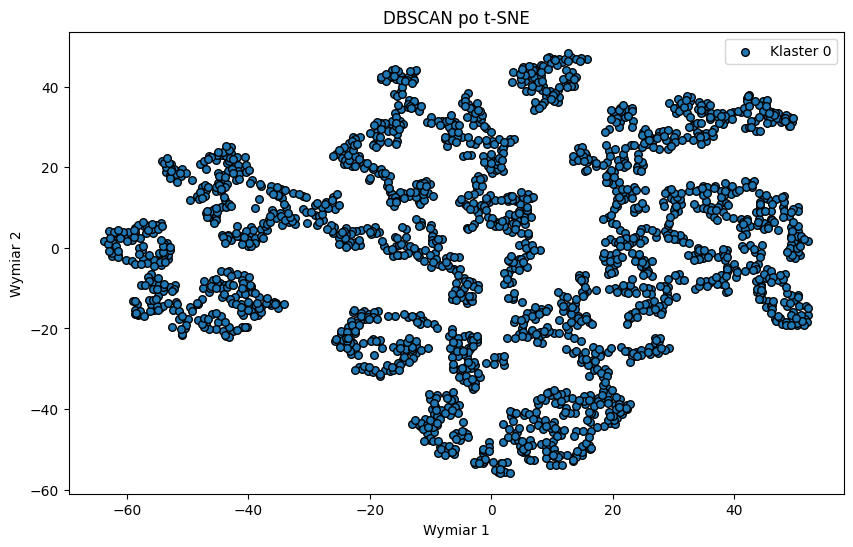

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Standaryzacja — DBSCAN działa lepiej po standaryzacji
X_scaled = StandardScaler().fit_transform(X_tsne)

# Dopasowanie DBSCAN
dbscan = DBSCAN(eps=2.2, min_samples=5)  # eps trzeba dostroić!
labels = dbscan.fit_predict(X_scaled)

# Liczba znalezionych klastrów (bez -1, czyli szumu)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Liczba znalezionych klastrów: {n_clusters}")

# Wizualizacja
plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = [plt.cm.tab20(i) for i in range(len(unique_labels))]

for k, col in zip(unique_labels, colors):
    class_member_mask = (labels == k)
    xy = X_tsne[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], label=f'Klaster {k}' if k != -1 else 'Szum', s=30, edgecolors='k')

plt.title("DBSCAN po t-SNE")
plt.xlabel("Wymiar 1")
plt.ylabel("Wymiar 2")
plt.legend()
plt.show()

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops
import torch
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import seaborn as sns

In [2]:
input_folder_siirt = 'd:/PWW/ML/projekt2/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio'
input_folder_kirmizi = 'd:/PWW/ML/projekt2/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio'

Haralick

In [3]:
def extract_haralick_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
    gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    features = {
        'contrast': graycoprops(glcm, 'contrast')[0, 0],
        'dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0, 0],
        'energy': graycoprops(glcm, 'energy')[0, 0],
        'correlation': graycoprops(glcm, 'correlation')[0, 0],
        'ASM': graycoprops(glcm, 'ASM')[0, 0]
    }
    return features

In [4]:
data = []

for filename in os.listdir(input_folder_siirt):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_siirt, filename)
        image = cv2.imread(path)

        features = extract_haralick_features(image)
        features['filename'] = filename
        data.append(features)

haralick_siirt = pd.DataFrame(data)
haralick_siirt.tail()  

,contrast,dissimilarity,homogeneity,energy,correlation,ASM,filename
911,45.972026,1.114780,0.865579,0.754675,0.997199,0.569535,siirt 95.jpg
912,41.401313,1.267501,0.822967,0.707885,0.997742,0.501101,siirt 96.jpg
913,38.644151,0.900846,0.879717,0.745254,0.997923,0.555404,siirt 97.jpg
914,39.446255,0.972577,0.857265,0.744686,0.997567,0.554557,siirt 98.jpg
915,44.381085,1.108130,0.854626,0.706164,0.997677,0.498667,siirt 99.jpg


In [5]:
data = []

for filename in os.listdir(input_folder_kirmizi):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_kirmizi, filename)
        image = cv2.imread(path)

        features = extract_haralick_features(image)
        features['filename'] = filename
        data.append(features)

haralick_kirmizi = pd.DataFrame(data)
haralick_kirmizi.tail() 

,contrast,dissimilarity,homogeneity,energy,correlation,ASM,filename
1227,66.806032,1.677001,0.822345,0.756322,0.994709,0.572023,kirmizi 995.jpg
1228,69.525376,1.354524,0.874626,0.784850,0.994870,0.615990,kirmizi 996.jpg
1229,130.264535,2.463439,0.772284,0.688695,0.993235,0.474300,kirmizi 997.jpg
1230,49.064023,0.934713,0.875263,0.765103,0.996498,0.585382,kirmizi 998.jpg
1231,67.272933,1.292443,0.849648,0.743461,0.996177,0.552735,kirmizi 999.jpg


In [6]:
df_haralick = pd.concat([haralick_kirmizi, haralick_siirt], ignore_index=True)
df_haralick.tail()

,contrast,dissimilarity,homogeneity,energy,correlation,ASM,filename
2143,45.972026,1.114780,0.865579,0.754675,0.997199,0.569535,siirt 95.jpg
2144,41.401313,1.267501,0.822967,0.707885,0.997742,0.501101,siirt 96.jpg
2145,38.644151,0.900846,0.879717,0.745254,0.997923,0.555404,siirt 97.jpg
2146,39.446255,0.972577,0.857265,0.744686,0.997567,0.554557,siirt 98.jpg
2147,44.381085,1.108130,0.854626,0.706164,0.997677,0.498667,siirt 99.jpg


Gabor

In [7]:
def extract_gabor_features(image, ksize=31):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128)) 

    num = 0
    features = {}

    # Parametry: 4 kąty × 3 częstotliwości = 12 cech
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # kąty: 0°, 45°, 90°, 135°
    lambdas = [4, 8, 16]  # długości fal (częstotliwości)

    for theta in thetas:
        for lam in lambdas:
            kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta, lambd=lam, gamma=0.5, psi=0)
            filtered = cv2.filter2D(gray, cv2.CV_8UC3, kernel)

            mean_val = filtered.mean()
            std_val = filtered.std()

            features[f'gabor_mean_{num}'] = mean_val
            features[f'gabor_std_{num}'] = std_val
            num += 1

    return features

In [8]:
data = []

for filename in os.listdir(input_folder_siirt):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_siirt, filename)
        image = cv2.imread(path)

        features = extract_gabor_features(image)
        features['filename'] = filename
        data.append(features)

gabor_siirt = pd.DataFrame(data)
gabor_siirt.head()

,gabor_mean_0,gabor_std_0,gabor_mean_1,gabor_std_1,gabor_mean_2,gabor_std_2,gabor_mean_3,gabor_std_3,gabor_mean_4,gabor_std_4,...,gabor_std_7,gabor_mean_8,gabor_std_8,gabor_mean_9,gabor_std_9,gabor_mean_10,gabor_std_10,gabor_mean_11,gabor_std_11,filename
0,11.804626,35.552678,70.621033,104.441736,103.211243,124.272890,14.477295,38.403300,83.056091,105.946698,...,107.347170,97.969604,123.217738,21.667114,57.945056,71.403992,108.034569,96.462891,122.388672,siirt (1).jpg
1,11.654968,35.024918,69.903931,103.052138,107.362671,124.809673,15.048157,43.029285,75.156494,108.059521,...,106.302894,87.409058,120.342731,13.872620,38.624721,76.613159,107.820269,106.988281,123.808118,siirt (10).jpg
2,12.331177,37.503944,71.613159,104.123739,106.682434,124.675550,16.637695,45.853508,76.064575,107.181780,...,105.891417,86.370544,119.948407,16.760376,44.691049,76.586853,108.299351,104.540344,123.554394,siirt (11).jpg
3,12.961243,34.531061,81.934937,107.672203,117.942200,126.055984,20.401733,49.832679,84.950806,110.494792,...,108.857213,105.482117,124.678765,18.262817,46.056072,89.616638,111.426744,121.532043,125.262626,siirt (12).jpg
4,12.198425,35.172555,66.668884,99.807637,105.396545,124.552917,16.920654,43.593994,76.983643,104.129418,...,103.698088,90.539734,121.251735,20.020874,52.890066,69.968567,106.453616,98.253662,122.575611,siirt (13).jpg


In [9]:
data = []

for filename in os.listdir(input_folder_kirmizi):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_kirmizi, filename)
        image = cv2.imread(path)

        features = extract_gabor_features(image)
        features['filename'] = filename
        data.append(features)

gabor_kirmizi = pd.DataFrame(data)
gabor_kirmizi.head()

,gabor_mean_0,gabor_std_0,gabor_mean_1,gabor_std_1,gabor_mean_2,gabor_std_2,gabor_mean_3,gabor_std_3,gabor_mean_4,gabor_std_4,...,gabor_std_7,gabor_mean_8,gabor_std_8,gabor_mean_9,gabor_std_9,gabor_mean_10,gabor_std_10,gabor_mean_11,gabor_std_11,filename
0,21.411682,61.505268,54.381836,99.071107,73.028625,114.532724,12.913452,35.899159,62.627869,99.192261,...,93.767160,93.472412,121.677122,14.922241,41.046882,59.528137,99.686999,87.773315,119.381028,kirmizi (1).jpg
1,7.828857,26.389756,59.902710,97.580418,94.689514,122.071739,10.422363,30.217117,65.028381,100.623397,...,100.882913,73.998840,115.023314,16.956299,47.871706,60.505615,101.423838,87.762390,119.435013,kirmizi (10).jpg
2,22.269836,60.886718,67.563843,105.425499,84.126404,119.313909,14.885010,40.694291,71.601746,105.084551,...,98.459246,108.827942,124.829780,15.273682,40.145196,74.014832,105.701808,109.160583,123.933092,kirmizi (11).jpg
3,10.266602,34.737565,49.308350,91.214318,78.986816,116.882629,16.382263,48.326797,52.624634,96.216591,...,95.214685,60.572937,107.815333,13.403870,39.362585,53.521667,95.993242,80.526245,116.685993,kirmizi (12).jpg
4,11.451233,36.757132,56.303467,96.946957,86.388123,119.699396,12.184509,36.231900,64.917114,98.645501,...,100.942564,73.208374,114.658749,21.013977,59.625736,56.675720,101.009720,77.143799,115.740314,kirmizi (13).jpg


In [10]:
df_gabor = pd.concat([gabor_kirmizi, gabor_siirt], ignore_index=True)
df_gabor.tail()

,gabor_mean_0,gabor_std_0,gabor_mean_1,gabor_std_1,gabor_mean_2,gabor_std_2,gabor_mean_3,gabor_std_3,gabor_mean_4,gabor_std_4,...,gabor_std_7,gabor_mean_8,gabor_std_8,gabor_mean_9,gabor_std_9,gabor_mean_10,gabor_std_10,gabor_mean_11,gabor_std_11,filename
2143,19.151794,55.612167,60.753357,103.635110,75.913086,115.899394,13.056335,37.258358,69.025269,104.512217,...,99.939964,97.931519,122.862565,11.633057,31.739348,69.339355,104.967860,95.211365,121.416731,siirt 95.jpg
2144,20.928467,54.959372,66.970947,106.555196,92.590393,121.789697,15.576050,42.505830,80.118347,109.604707,...,105.083419,107.593262,124.839483,14.271118,39.096349,78.349182,109.558778,108.875244,124.206741,siirt 96.jpg
2145,14.940491,47.792226,66.048889,106.331310,80.012390,117.630219,11.525940,36.885745,75.319885,106.440133,...,104.159172,99.722107,123.407947,15.511414,45.776162,72.960815,108.901138,92.253540,120.910587,siirt 97.jpg
2146,17.197266,51.502445,63.647644,104.925062,79.388611,117.446997,11.187805,29.437818,71.512817,102.815122,...,100.655349,101.621094,123.651247,12.809021,37.981890,69.093079,106.733093,91.151489,120.578330,siirt 98.jpg
2147,16.334534,47.265773,73.464233,110.035625,89.073303,120.936403,13.281433,37.431351,81.734802,110.794128,...,105.825515,110.701172,125.216568,14.544739,40.598718,79.370300,109.884212,108.819641,124.215641,siirt 99.jpg


Entropia

In [3]:
def image_entropy(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist.ravel() / hist.sum() 
    hist = hist[hist > 0]  
    return entropy(hist, base=2) 

In [4]:
data = []

for filename in os.listdir(input_folder_siirt):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_siirt, filename)
        image = cv2.imread(path)
        ent = image_entropy(image)
        data.append({
            'filename': filename,
            'entropy': ent
        })

siirt_entropy = pd.DataFrame(data)

In [5]:
print("Średnia entropia:", siirt_entropy["entropy"].mean())

Średnia entropia: 2.673027683461545


In [6]:
data = []

for filename in os.listdir(input_folder_kirmizi):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_kirmizi, filename)
        image = cv2.imread(path)
        ent = image_entropy(image)
        data.append({
            'filename': filename,
            'entropy': ent
        })

kirmizi_entropy = pd.DataFrame(data)

In [7]:
print("Średnia entropia:", kirmizi_entropy["entropy"].mean())

Średnia entropia: 2.4017096824975277


In [8]:
df_entropy = pd.concat([kirmizi_entropy, siirt_entropy], ignore_index=True)
df_entropy.tail()

,filename,entropy
2143,siirt 95.jpg,2.418170
2144,siirt 96.jpg,2.759802
2145,siirt 97.jpg,2.386598
2146,siirt 98.jpg,2.534749
2147,siirt 99.jpg,2.771892


ResNet

In [17]:
# Ładowanie modelu ResNet50 (pretrenowany, bez klasyfikatora)
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Usuwamy ostatnią warstwę (klasyfikator)
model.eval()

# Przekształcenia obrazu do formatu ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # domyślne dla ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

C:\Users\New\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\New\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
features_list = []
filenames = []

for filename in tqdm(os.listdir(input_folder_siirt)):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_siirt, filename)
        image = Image.open(path).convert("RGB")

        img_tensor = transform(image).unsqueeze(0) 

        with torch.no_grad():
            embedding = model(img_tensor).squeeze().numpy() 

        features_list.append(embedding)
        filenames.append(filename)
        
siirt_resnet = pd.DataFrame(features_list)
siirt_resnet["filename"] = filenames

100%|████████████████████████████████████████████████████████████████████████████████| 916/916 [02:57<00:00,  5.17it/s]


In [19]:
features_list = []
filenames = []

for filename in tqdm(os.listdir(input_folder_kirmizi)):
    if filename.lower().endswith(('.jpg', '.png')):
        path = os.path.join(input_folder_kirmizi, filename)
        image = Image.open(path).convert("RGB")

        img_tensor = transform(image).unsqueeze(0) 

        with torch.no_grad():
            embedding = model(img_tensor).squeeze().numpy() 

        features_list.append(embedding)
        filenames.append(filename)

kirmizi_resnet = pd.DataFrame(features_list)
kirmizi_resnet["filename"] = filenames

100%|██████████████████████████████████████████████████████████████████████████████| 1232/1232 [04:00<00:00,  5.12it/s]


In [20]:
df_resnet = pd.concat([kirmizi_resnet, siirt_resnet], ignore_index=True)

In [21]:
df_all = pd.merge(df_resnet, df_entropy, on="filename")
df_all = pd.merge(df_all, df_gabor, on="filename")
df_all = pd.merge(df_all, df_haralick, on="filename")

In [22]:
df_all.head()

,0,1,2,3,4,5,6,7,8,9,...,gabor_mean_10,gabor_std_10,gabor_mean_11,gabor_std_11,contrast,dissimilarity,homogeneity,energy,correlation,ASM
0,0.088716,0.421523,0.042320,0.000000,0.011499,0.552581,0.172038,0.023663,0.794875,0.040689,...,59.528137,99.686999,87.773315,119.381028,54.777140,1.268614,0.858435,0.769645,0.995542,0.592354
1,0.221219,0.547398,0.065916,0.000000,0.039931,0.270826,0.249120,0.125911,0.694619,0.061505,...,60.505615,101.423838,87.762390,119.435013,19.389121,0.699444,0.886433,0.759725,0.998601,0.577182
2,0.133558,0.215000,0.157012,0.137602,0.000000,1.038146,0.564119,0.062571,0.672270,0.172667,...,74.014832,105.701808,109.160583,123.933092,53.659777,1.327268,0.826115,0.717864,0.996185,0.515329
3,0.244536,0.648952,0.027799,0.000000,0.176301,1.081130,0.311545,0.063491,0.780110,0.099736,...,53.521667,95.993242,80.526245,116.685993,33.492070,0.802309,0.905369,0.817073,0.997639,0.667608
4,0.385452,0.750327,0.051370,0.016437,0.001399,0.464605,0.190554,0.117090,0.431787,0.071847,...,56.675720,101.009720,77.143799,115.740314,41.764886,1.098403,0.879700,0.778672,0.997150,0.606330


PCA

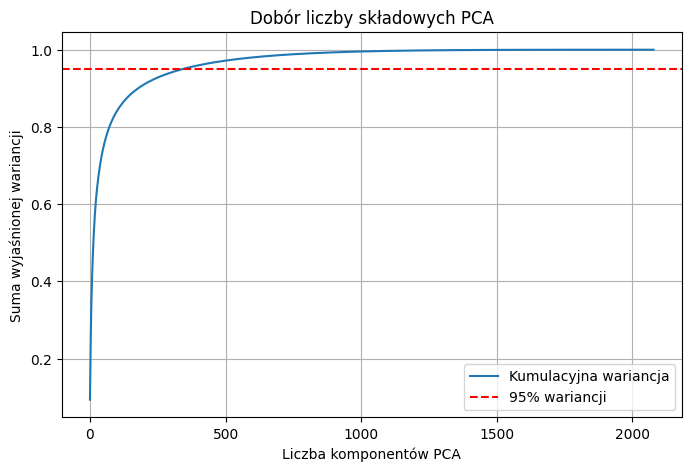

Wystarczy 344 komponentów do zachowania 95% informacji.


In [24]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df_all.drop(columns=["filename"])
X.columns = X.columns.astype(str)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA()
X_pca_all = pca.fit_transform(X_scaled) 

cum_var = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(cum_var, label="Kumulacyjna wariancja")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% wariancji")
plt.xlabel("Liczba komponentów PCA")
plt.ylabel("Suma wyjaśnionej wariancji")
plt.title("Dobór liczby składowych PCA")
plt.grid(True)
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Wystarczy {n_components} komponentów do zachowania 95% informacji.")

In [25]:
pca_opt = PCA(n_components=n_components)
X_resnet_pca = pca_opt.fit_transform(X_scaled)

df_resnet_pca = pd.DataFrame(X_resnet_pca, columns=[f"PC{i+1}" for i in range(n_components)])
df_resnet_pca["filename"] = df_resnet["filename"].values

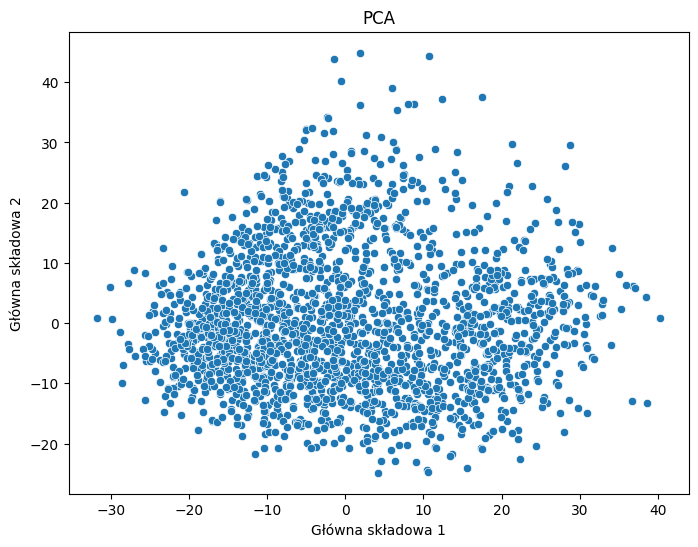

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])


plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title('PCA')
plt.xlabel('Główna składowa 1')
plt.ylabel('Główna składowa 2')
plt.show()

t-NSE

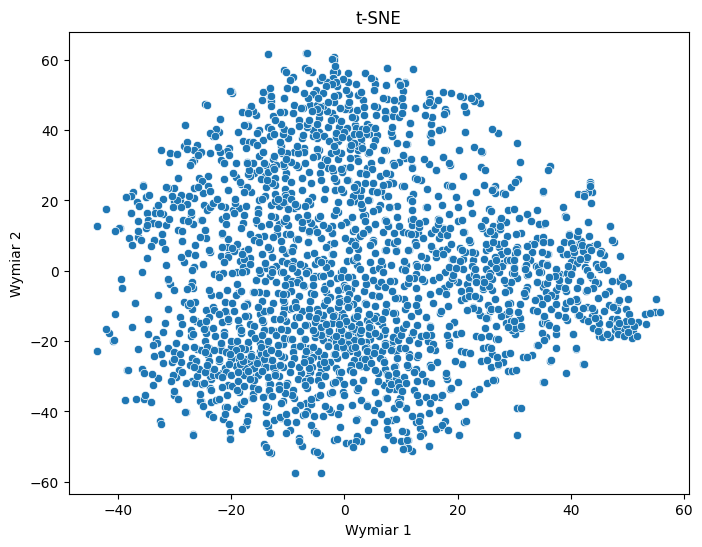

In [35]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2')
plt.title('t-SNE')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()

vit

In [36]:
import timm
import torch
import torchvision.transforms as T

model = timm.create_model('vit_small_patch16_224_dino', pretrained=True)
model.eval()

C:\Users\New\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:126: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [37]:
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
embeddings = []
filenames = []
for fname in os.listdir(input_folder_siirt):
    img = Image.open(os.path.join(input_folder_siirt, fname)).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        feat = model.forward_features(img_tensor)
        emb = feat.mean(dim=1).squeeze().numpy()

    embeddings.append(emb)
    filenames.append(fname)
import pandas as pd
df_siirt_vit = pd.DataFrame(embeddings)
df_siirt_vit["filename"] = filenames

In [39]:
embeddings = []
filenames = []
for fname in os.listdir(input_folder_kirmizi):
    img = Image.open(os.path.join(input_folder_kirmizi, fname)).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        feat = model.forward_features(img_tensor)
        emb = feat.mean(dim=1).squeeze().numpy()

    embeddings.append(emb)
    filenames.append(fname)
import pandas as pd
df_kirmizi_vit = pd.DataFrame(embeddings)
df_kirmizi_vit["filename"] = filenames

In [40]:
df_vit = pd.concat([df_kirmizi_vit, df_siirt_vit], ignore_index=True)

In [41]:
def extract_shape_features(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None 
    cnt = max(contours, key=cv2.contourArea)

    # Cechy geometryczne
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    extent = area / (w * h)
    roundness = (4 * np.pi * area) / (perimeter ** 2 + 1e-7) 

    # Hu Moments
    moments = cv2.moments(cnt)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10) 

    # wektor cech
    features = {
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "roundness": roundness,
    }

    for i in range(7):
        features[f"hu{i+1}"] = hu_log[i]

    return features

In [42]:
feature_list = []

for fname in os.listdir(input_folder_siirt):
    if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
        fpath = os.path.join(input_folder_siirt, fname)
        feats = extract_shape_features(fpath)
        if feats:
            feats["filename"] = fname
            feature_list.append(feats)

df_shapes_siirt = pd.DataFrame(feature_list)

In [43]:
feature_list = []

for fname in os.listdir(input_folder_kirmizi):
    if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
        fpath = os.path.join(input_folder_kirmizi, fname)
        feats = extract_shape_features(fpath)
        if feats:
            feats["filename"] = fname
            feature_list.append(feats)

df_shapes_kirmizi = pd.DataFrame(feature_list)

In [44]:
df_shapes = pd.concat([df_shapes_kirmizi, df_shapes_siirt], ignore_index=True)

In [45]:
df_shapes_vit = pd.merge(df_vit, df_shapes, on="filename")

In [46]:
df_shapes_vit.columns = df_shapes_vit.columns.astype(str)

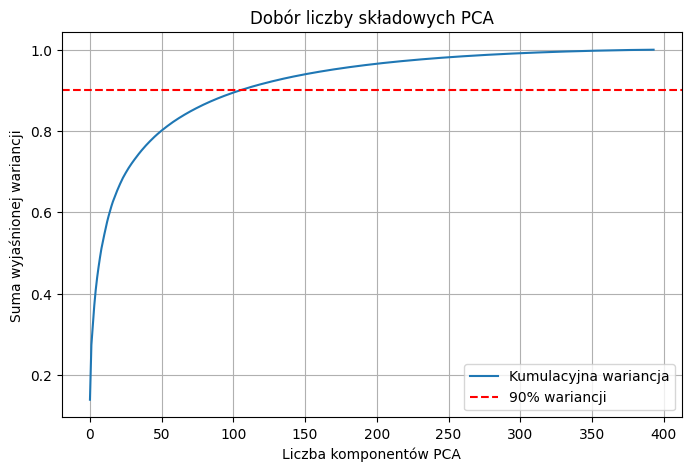

Wystarczy 106 komponentów do zachowania 90% informacji.


In [47]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df_shapes_vit.drop(columns=["filename"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA()
X_pca_all = pca.fit_transform(X_scaled) 

cum_var = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(cum_var, label="Kumulacyjna wariancja")
plt.axhline(y=0.9, color='r', linestyle='--', label="90% wariancji")
plt.xlabel("Liczba komponentów PCA")
plt.ylabel("Suma wyjaśnionej wariancji")
plt.title("Dobór liczby składowych PCA")
plt.grid(True)
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.9) + 1
print(f"Wystarczy {n_components} komponentów do zachowania 90% informacji.")

In [48]:
pca_opt = PCA(n_components=n_components)
X_vit_pca = pca_opt.fit_transform(X_scaled)

df_vit_pca = pd.DataFrame(X_vit_pca, columns=[f"PC{i+1}" for i in range(n_components)])
df_vit_pca["filename"] = df_shapes_vit["filename"].values

In [49]:
df_vit_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC98,PC99,PC100,PC101,PC102,PC103,PC104,PC105,PC106,filename
0,7.304579,-9.837412,-3.997300,1.985669,0.479490,-1.261128,1.888991,0.396564,1.509667,1.568996,...,0.270375,1.115003,0.624607,0.002653,0.440482,0.527439,-0.413675,-0.634967,0.047654,kirmizi (1).jpg
1,6.040486,-10.007254,0.162019,-4.587778,-4.879454,3.868067,4.239978,-6.237411,0.135007,0.427575,...,-0.441588,0.730711,-0.597203,-0.201585,-0.691033,0.251365,0.668626,1.254270,-0.737442,kirmizi (10).jpg
2,-2.948353,-3.131220,-3.108559,6.225791,-0.665489,1.051405,-4.210720,-1.120365,1.683366,0.319223,...,-0.012054,0.717149,0.493427,-0.284825,0.098308,-0.467859,-0.317056,-1.050162,-0.406318,kirmizi (11).jpg
3,14.987496,-3.274644,2.602209,1.914061,-8.532184,3.967622,1.012263,0.876511,-2.551196,3.432228,...,0.116489,1.779131,-0.952804,1.361271,0.107112,-0.167841,0.381650,-1.098367,0.628518,kirmizi (12).jpg
4,6.504495,-9.850962,12.350292,-2.092597,-7.669635,4.985795,-4.742769,-3.898370,-4.132973,1.058243,...,0.962445,-0.127076,-0.869402,0.575872,0.244866,0.562369,-0.363503,0.273952,-0.798976,kirmizi (13).jpg


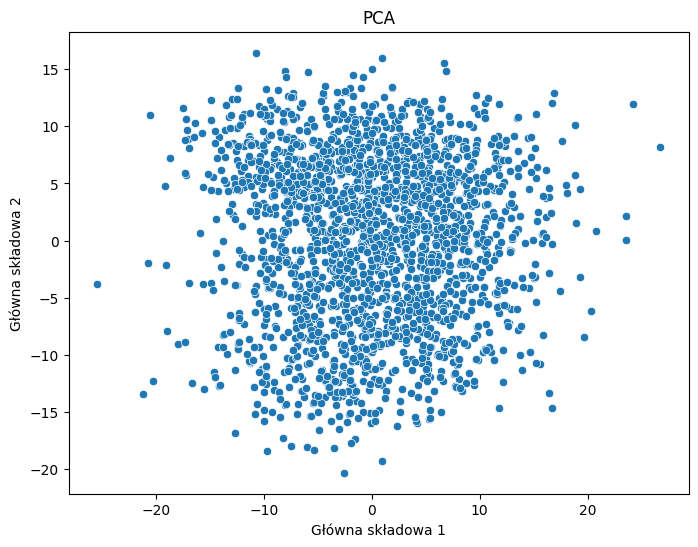

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])


plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title('PCA')
plt.xlabel('Główna składowa 1')
plt.ylabel('Główna składowa 2')
plt.show()

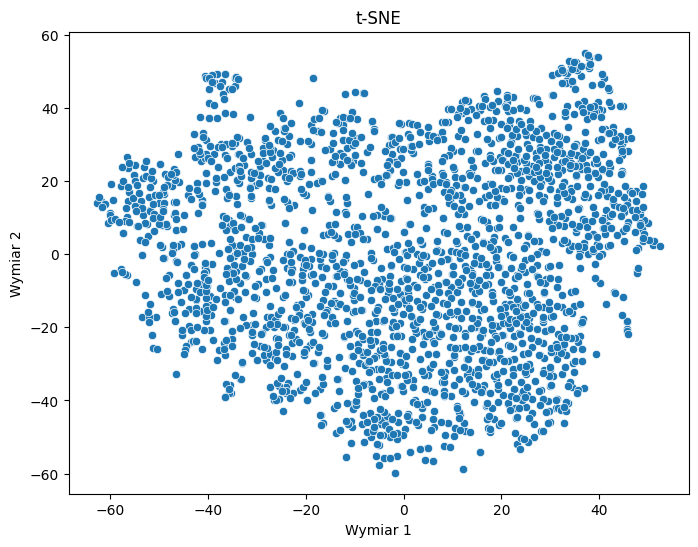

In [64]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2')
plt.title('t-SNE')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()